In [1]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2

# plot matplots nicely
%matplotlib inline  

In [2]:
from stericheight.data_handler import *
from stericheight.steric_height import *
from stericheight.plotting_fns import PlottingFns
from stericheight.utils import Utils
from load_meop import MEOP
from region import Region
from composite import Composite
pfns = PlottingFns()

In [3]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cmocean
import xesmf as xe
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm import tqdm
from gsw import density


ARGO = '/nfs/b0133/eejco/data/ARGO/DataSelection_a0ad0869-68c3-4b7d-af4c-9c010ab6e378/'

In [4]:
sla = SLA(deg=0.25).da
sice = xr.open_dataset('../data/NSIDC/sice_processed.nc')
sice = sice.__xarray_dataarray_variable__
elevation_ = GEBCO(coarsen_factor=40).ds.elevation


In [5]:
def sanom(da):
    return da.groupby('time.month') - da.groupby('time.month').mean()

In [6]:
extent =[100,160,-69,-65.2]
extent_mertz =[138.5,143,-67,-65.6]
extent_vcbay = [106,114,-70,-65.2]
extent_voyeykov = [121,128,-70,-65.4]
elevation = elevation_.sel(latitude = slice(extent[2], extent[3]), longitude = slice(extent[0],extent[1]))


In [7]:
# set up neutral density
from scipy.optimize import root_scalar

tlims = [-2.1,0.4]
slims = [32.9,34.9]
temprange = np.linspace(tlims[0],tlims[1],1000)

def find_salinity_for_temperture(t,yn):
    def density_difference(s):
        return density.sigma0(s, t) - yn

    return np.round(root_scalar(density_difference, bracket=(32,37), method='brentq').root,3)

s_yn2800 = [find_salinity_for_temperture(t,28) for t in temprange]
s_yn2755 = [find_salinity_for_temperture(t,27.55) for t in temprange]
s_yn2827 = [find_salinity_for_temperture(t,28.27) for t in temprange]


In [ ]:
# setup
# on/off shelf
# with/without trend
# local/widespread region
# months before/after

<GeoAxes: xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>

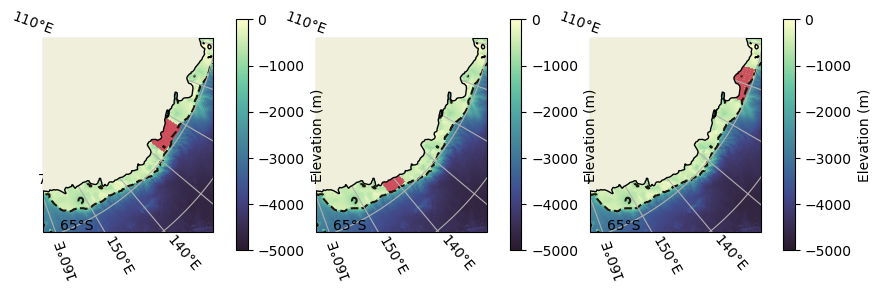

In [8]:
shelf = Region('EA Shelf',extent,elevation_,min_elevation=-1000)
voyeykov = Region('Voyeykov',extent_voyeykov)
mertz = Region('Mertz',extent_mertz)
vcbay = Region('Vincennes Bay',extent_vcbay)
fig, ax = plt.subplots(1,3,figsize=(10,3),subplot_kw={'projection':ccrs.SouthPolarStereo()})
voyeykov.plot_region(ax=ax[0],extent=extent)
mertz.plot_region(ax=ax[1],extent=extent)
vcbay.plot_region(ax=ax[2],extent=extent)

In [55]:
meop_voyeykov=MEOP(extent=extent_voyeykov)
meop_voyeykov.load_profiles()


100%|██████████| 33/33 [00:08<00:00,  3.74it/s]


In [9]:
meop_mertz=MEOP(extent=extent_mertz)
meop_mertz.load_profiles()

100%|██████████| 81/81 [02:23<00:00,  1.78s/it]


In [ ]:
meop_vcbay=MEOP(extent=extent_vcbay)
meop_vcbay.load_profiles()

100%|██████████| 72/72 [01:19<00:00,  1.11s/it]


In [8]:
meop=MEOP(extent=extent)
meop.load_profiles()

100%|██████████| 193/193 [04:02<00:00,  1.26s/it]


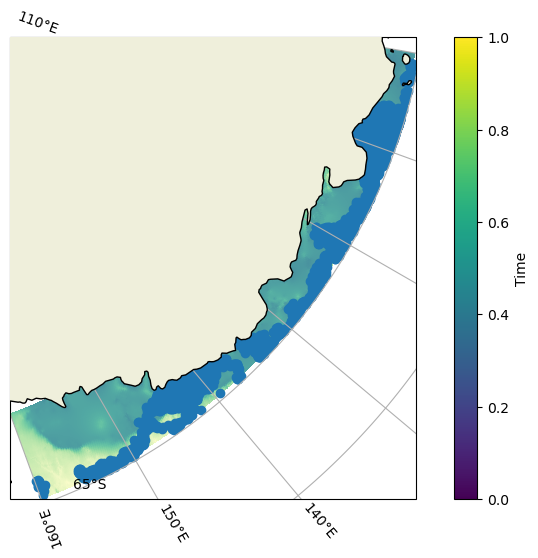

In [9]:
fig, ax = plt.subplots(figsize=(10,6), subplot_kw={'projection':ccrs.SouthPolarStereo()})
pfns.sp(ax=ax,da=elevation,extent=extent,cmap=cmocean.cm.deep)
# im=ax.scatter(meop_voyeykov.df.longitude, meop_voyeykov.df.latitude, transform=ccrs.PlateCarree())
# im=ax.scatter(meop_mertz.df.longitude, meop_mertz.df.latitude, transform=ccrs.PlateCarree())
# im=ax.scatter(meop_vcbay.df.longitude, meop_vcbay.df.latitude, transform=ccrs.PlateCarree())
im=ax.scatter(meop.df.longitude, meop.df.latitude, transform=ccrs.PlateCarree())


cbar = plt.colorbar(im, label='Time')


In [11]:
sla_shelf = shelf.crop_da(sla)
background_data = sanom(sla_shelf).mean(['latitude','longitude'])#-sla_shelf.mean()
idx_data = background_data.rolling(time=12,center=True).mean('time')

In [15]:
cmp.t_pos

<xarray.DataArray 'TEMP_ADJUSTED' (time: 527, pressure: 45)> Size: 95kB
array([[       nan,        nan,        nan, ..., -1.8771952, -1.890092 ,
               nan],
       [       nan, -1.8785787, -1.8782934, ...,        nan,        nan,
               nan],
       [       nan, -1.8825815, -1.8822773, ...,        nan,        nan,
               nan],
       ...,
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [-1.7664317, -1.6502184, -1.534005 , ..., -1.7919867, -1.8025193,
               nan]], dtype=float32)
Coordinates:
  * pressure  (pressure) float32 180B 4.0 6.0 8.0 10.0 ... 190.7 200.0 300.0
  * time      (time) datetime64[ns] 4kB 2007-08-01T03:30:00 ... 2015-01-17T15...
Attributes:
    long_name:  SEA TEMPERATURE IN SITU ITS-90 SCALE
    units:      degree_Celsius
    valid_min:  -2.0
    valid_max:  40.0
    comment:    In situ measurement

In [19]:
def freq_plot(da_time,ax0,ax1):
    monthly = da_time.groupby('time.month').count()
    yearly = da_time.groupby('time.year').count()
    ax0.bar(monthly.month,monthly)
    ax0.set_xticks(np.arange(1,13))
    ax0.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
    ax0.set_ylabel('Total number of profiles')

    ax1.bar(yearly.year,yearly)
    ax1.set_xlim([2002,2022])
    ax1.set_ylabel('Total number of profiles')


In [ ]:
# sensitivity tests
# on/off shelf
onshelf = True
if onshelf:
    backgroi
# with/without trend
# local/widespread region
# months before/after

In [134]:
cmp.df_both

AttributeError: 'Composite' object has no attribute 'df_both'

In [12]:
background_data = sanom(sla_shelf).mean(['latitude','longitude'])
background_data = utls.detrend_dim(background_data,'time')
idx_data = background_data.rolling(time=12,center=True).mean('time')

cmp = Composite(idx_data,'SLA')
cmp.add_meop(meop_mertz,tlims=tlims,slims=slims)

In [ ]:
fig = plt.figure(figsize=(12,18))
gs = fig.add_gridspec(10,4)

# FIG1: SLA/SAM TIMESERIES
ax1 = fig.add_subplot(gs[0, :])

cmp.composite_timeseries(ax1,background_data,bg_name='Seasonal Anomaly')
# FIG2: SLA MAP
ax2 = fig.add_subplot(gs[1:3, 0:2],projection=ccrs.SouthPolarStereo())
ax3 = fig.add_subplot(gs[1:3, 2:4],projection=ccrs.SouthPolarStereo())
cmp.posneg_map([ax2,ax3],sanom(shelf.crop_da(sla)),'SLA',12,extent,label_loc=[130,-80])

# FIG3: SLA closeup
ax4 = fig.add_subplot(gs[3:5, 0:2],projection=ccrs.SouthPolarStereo())
ax5 = fig.add_subplot(gs[3:5, 2:4],projection=ccrs.SouthPolarStereo())
cmp.posneg_map([ax4,ax5],sanom(shelf.crop_da(sla)),'SLA',12,extent_mertz,add_profiles=True)

n = 5
cmp.ts_freq_plot([ 
    fig.add_subplot(gs[n,0]),
    fig.add_subplot(gs[n,1]),
    fig.add_subplot(gs[n,2]),
    fig.add_subplot(gs[n,3]),
])

# FIG4: TS DESNITY
ax6 = fig.add_subplot(gs[6:8,0:2])
ax7 = fig.add_subplot(gs[6:8,2:4])
cmp.ts_density([ax6,ax7])

# FIG5: TS PROFILES
ax8 = fig.add_subplot(gs[8:10,0])
ax9 = fig.add_subplot(gs[8:10,1])
ax10 = fig.add_subplot(gs[8:10,2])
ax11 = fig.add_subplot(gs[8:10,3])
cmp.ts_profiles([ax8,ax9,ax10,ax11])



SyntaxError: closing parenthesis ')' does not match opening parenthesis '[' (3065949665.py, line 20)

In [24]:
get_posneg_ts(meop,idx_positive)

ValueError: zero-size array to reduction operation fmin which has no identity

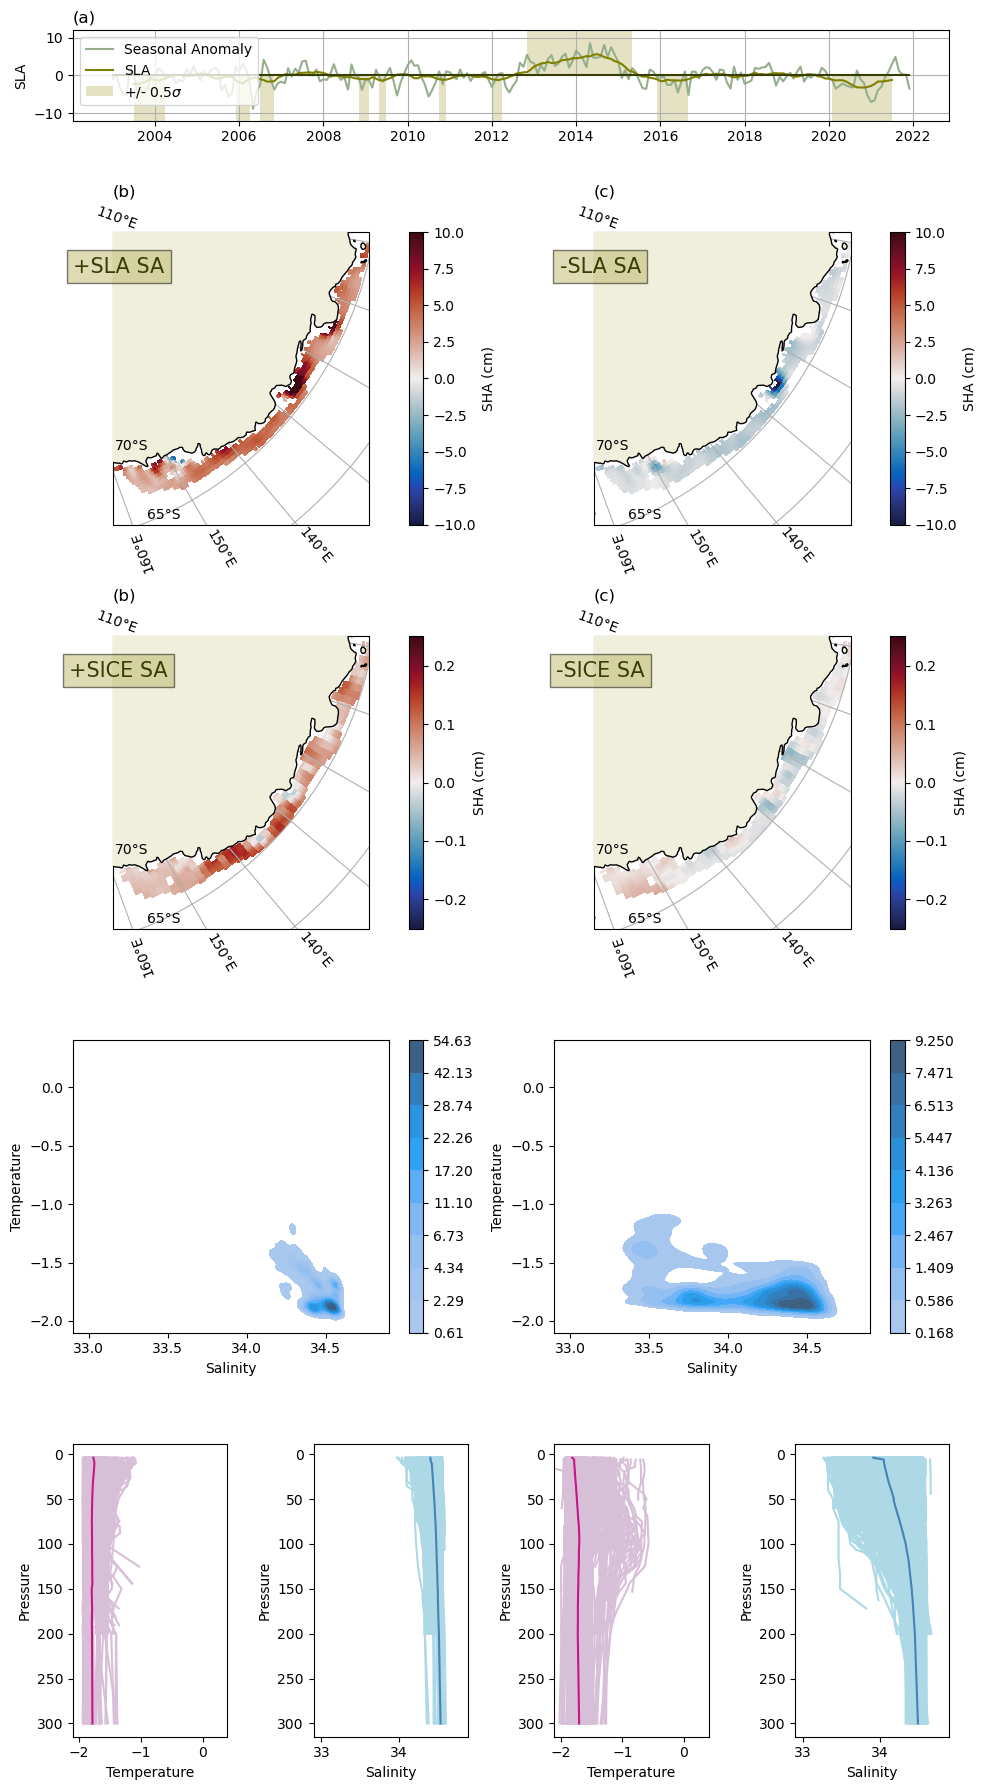

In [35]:
# COMPOSITE PLOT


# SET UP FIGURE
fig = plt.figure(figsize=(10,18))
gs = fig.add_gridspec(9,4)

tlims = [-2.1,0.4]
slims = [32.9,34.9]

t_pos, s_pos = get_posneg_ts(meop_mertz,idx_positive)
t_neg, s_neg = get_posneg_ts(meop_mertz,idx_negative)

# FIG1: SLA/SAM TIMESERIES
ax1 = fig.add_subplot(gs[0, :])

composite_timeseries(ax1,
                    idx_data,
                    'SLA',
                    idx_positive,
                    idx_negative,
                    limit_label,
                    bg1=background_data,
                    bg_name='Seasonal Anomaly')
# FIG2: SLA MAP
ax2 = fig.add_subplot(gs[1:3, 0:2],projection=ccrs.SouthPolarStereo())
ax3 = fig.add_subplot(gs[1:3, 2:4],projection=ccrs.SouthPolarStereo())
posneg_map([ax2,ax3],idx_positive,idx_negative,'SLA SA',sanom(sla_shelf),10)

# FIG3: SLA MAP
ax4 = fig.add_subplot(gs[3:5, 0:2],projection=ccrs.SouthPolarStereo())
ax5 = fig.add_subplot(gs[3:5, 2:4],projection=ccrs.SouthPolarStereo())
posneg_map([ax4,ax5],idx_positive,idx_negative,'SICE SA',sanom(shelf.crop_da(sice)),0.25)

# FIG4: TS DENSITY CONTOUR
ax6 = fig.add_subplot(gs[5:7,0:2])
ax7 = fig.add_subplot(gs[5:7,2:4])
def ts_axes(ax,im):
    ax.set_ylim(tlims)
    ax.set_xlim(slims)
    ax.set_xlabel('Salinity')
    ax.set_ylabel('Temperature')

ts_axes(ax6,sns.kdeplot(ax=ax6,x=s_pos.values.flatten(), y=t_pos.values.flatten(),fill=True, cbar=True, common_norm=True))
#ax6.scatter(x=s_pos.values.flatten(), y=t_pos.values.flatten())
ts_axes(ax7,sns.kdeplot(ax=ax7,x=s_neg.values.flatten(), y=t_neg.values.flatten(),fill=True, cbar=True))
#ax7.scatter(x=s_neg.values.flatten(), y=t_neg.values.flatten())


# FIG5: TS PROFILES
ax8 = fig.add_subplot(gs[7:9,0])
ax9 = fig.add_subplot(gs[7:9,1])
ax10 = fig.add_subplot(gs[7:9,2])
ax11 = fig.add_subplot(gs[7:9,3])

def plot_prof(ax,prof,xlabel,color,mean_color,lims):
    for lon in prof.longitude:
        ax.plot(prof.sel(longitude=lon),prof.pressure,color=color)
    ax.plot(prof.mean('longitude'),prof.pressure,color=mean_color)
    ax.invert_yaxis()
    ax.set_ylabel('Pressure')
    ax.set_xlabel(xlabel)
    ax.set_xlim(lims)

plot_prof(ax8,t_pos,'Temperature','thistle','mediumvioletred',tlims)
plot_prof(ax9,s_pos,'Salinity','lightblue','steelblue',slims)
plot_prof(ax10,t_neg,'Temperature','thistle','mediumvioletred',tlims)
plot_prof(ax11,s_neg,'Salinity','lightblue','steelblue',slims)




fig.tight_layout()


